# Логистическая регрессия

**Цель работы:** познакомиться с широко используемым методом бинарной классификации — логистической регрессией.

**Содержание работы:**
1. Сгенерировать матрицу признаков и вектор целей для задачи классификации.
2. Реализовать модель логистической регрессии методом градиентного спуска с нуля.
3. Оценить качество модели с помощью метрик accuracy и F1-score.
4. Построить библиотечную модель `LogisticRegression` из sklearn и сравнить результаты.

## 1. Импорт библиотек и генерация данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

Сгенерируем синтетический датасет для бинарной классификации: 1000 объектов, 2 признака (для визуализации), 2 информативных признака, 2 класса. Параметр `class_sep` задаёт расстояние (зазор) между классами.

In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    class_sep=2,
    random_state=1
)

print('Размер X:', X.shape)
print('Размер y:', y.shape)
pd.DataFrame(X).head()

Размер X: (1000, 2)
Размер y: (1000,)


,0,1
0,1.863411,0.087646
1,-1.530997,1.901182
2,-0.017224,-2.591112
3,-2.032039,-1.801162
4,4.620555,0.901124


## 2. Визуализация данных

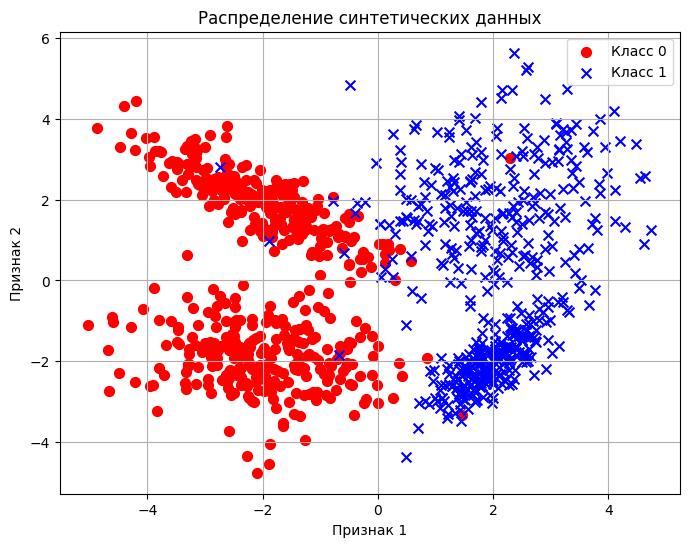

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], marker='o', c='r', s=50, label='Класс 0')
plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], marker='x', c='b', s=50, label='Класс 1')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Распределение синтетических данных')
plt.legend()
plt.grid(True)
plt.show()

Классы хорошо разделимы в пространстве признаков — это подтверждает, что логистическая регрессия будет эффективна.

## 3. Реализация логистической регрессии с нуля

Создадим два класса:
- **`SGD`** — базовый класс, реализующий градиентный спуск (универсальный);
- **`LogReg`** — модель логистической регрессии, наследующая `SGD` и реализующая сигмоиду, градиент и предсказание.

In [4]:
class SGD:
    """Базовый класс стохастического градиентного спуска"""

    def __init__(self, alpha=0.5, n_iters=1000):
        self.b = None
        self._alpha = alpha
        self._n_iters = n_iters

    def gradient_step(self, b, b_grad):
        return b - self._alpha * b_grad

    def optimize(self, X, y, start_b, n_iters):
        b = start_b.copy()
        for i in range(n_iters):
            b_grad = self.grad_func(X, y, b)
            b = self.gradient_step(b, b_grad)
        return b

    def fit(self, X, y):
        m = X.shape[1]
        start_b = np.ones(m)
        self.b = self.optimize(X, y, start_b, self._n_iters)


class LogReg(SGD):
    """Логистическая регрессия"""

    def sigmoid(self, X, b):
        return 1. / (1. + np.exp(-X.dot(b)))

    def grad_func(self, X, y, b):
        n = X.shape[0]
        grad = 1. / n * X.transpose().dot(self.sigmoid(X, b) - y)
        return grad

    def predict_proba(self, X):
        return self.sigmoid(X, self.b)

    def predict(self, X):
        y_pred = self.predict_proba(X) > 0.5
        return y_pred

Архитектура с разделением базового оптимизатора (`SGD`) и моделеспецифичного класса (`LogReg`) аналогична той, что используется в **sklearn**, и позволяет легко расширять модели.

## 4. Обучение собственной модели

Добавим фиктивный столбец единиц к матрице признаков для учёта свободного члена (intercept), обучим модель и оценим качество.

In [5]:
X_bias = np.hstack([np.ones(X.shape[0])[:, np.newaxis], X])

logreg = LogReg()
logreg.fit(X_bias, y)

y_pred = logreg.predict(X_bias)
y_pred_proba = logreg.predict_proba(X_bias)

ac = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
print(f'Собственная модель — accuracy = {ac:.4f}, F1-score = {f1:.4f}')

Собственная модель — accuracy = 0.9760, F1-score = 0.9761


## 5. Визуализация разделяющей поверхности (decision boundary)

Для наглядной демонстрации работы модели построим контурный график: создадим равномерную сетку в пространстве признаков, вычислим предсказанные вероятности в каждой точке и отобразим границу решения.

C:\Users\w1nore\AppData\Local\Temp\ipykernel_1216\1247261148.py:14: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], marker='x', c='b', s=50, edgecolors='k', label='Класс 1')


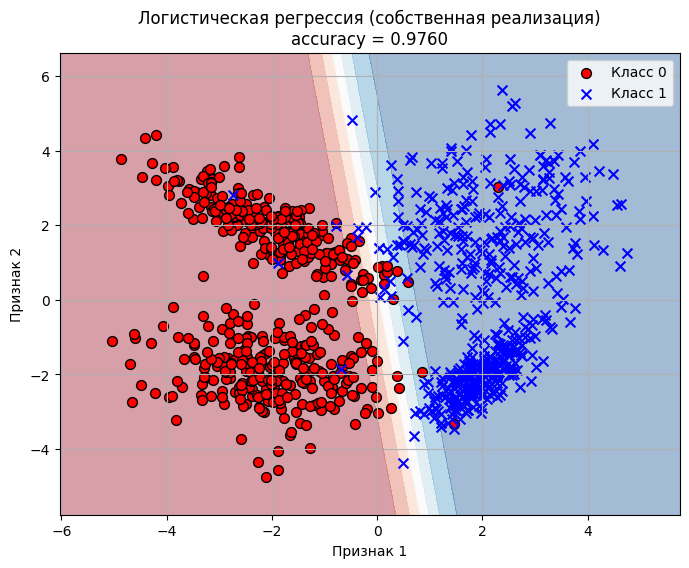

In [6]:
xx, yy = np.meshgrid(
    np.arange(X_bias.min(axis=0)[1] - 1, X_bias.max(axis=0)[1] + 1, 0.01),
    np.arange(X_bias.min(axis=0)[2] - 1, X_bias.max(axis=0)[2] + 1, 0.01)
)
XX = np.array(list(zip(xx.ravel(), yy.ravel()))).reshape((-1, 2))
XX = np.array([(1, *xx) for xx in XX])

Z = logreg.predict_proba(XX)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu')
plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], marker='o', c='r', s=50, edgecolors='k', label='Класс 0')
plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], marker='x', c='b', s=50, edgecolors='k', label='Класс 1')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title(f'Логистическая регрессия (собственная реализация)\naccuracy = {ac:.4f}')
plt.legend()
plt.grid(True)
plt.show()

Фоновый градиент показывает вероятность принадлежности к классу 1: синие области — высокая вероятность, красные — низкая. Линия, где вероятность равна 0.5, является разделяющей границей. Модель хорошо разделяет два класса.

## 6. Библиотечная модель LogisticRegression (sklearn)

In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

y_pred_lr = model.predict(X)
y_pred_lr_proba = model.predict_proba(X)

ac_lr = accuracy_score(y, y_pred_lr)
f1_lr = f1_score(y, y_pred_lr)
print(f'Библиотечная модель — accuracy = {ac_lr:.4f}, F1-score = {f1_lr:.4f}')

Библиотечная модель — accuracy = 0.9760, F1-score = 0.9761


### Визуализация библиотечной модели

C:\Users\w1nore\AppData\Local\Temp\ipykernel_1216\1402926395.py:12: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], marker='x', c='b', s=50, edgecolors='k', label='Класс 1')


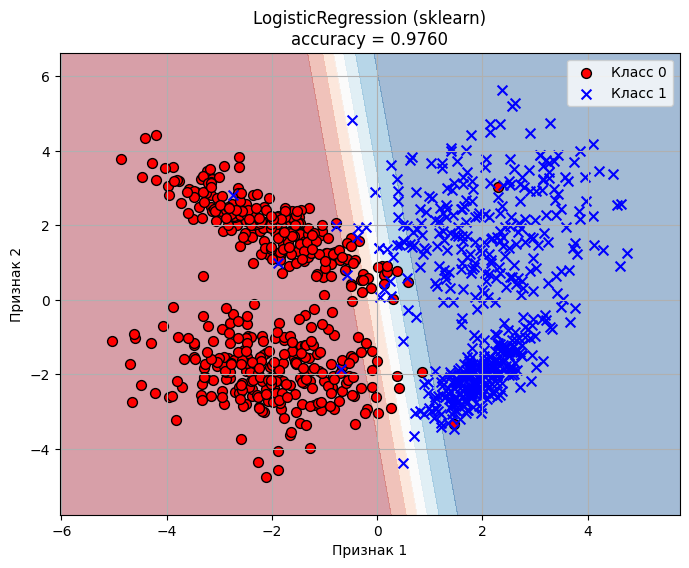

In [8]:
xx, yy = np.meshgrid(
    np.arange(X[:, 0].min() - 1, X[:, 0].max() + 1, 0.01),
    np.arange(X[:, 1].min() - 1, X[:, 1].max() + 1, 0.01)
)
XX_grid = np.c_[xx.ravel(), yy.ravel()]
Z_lr = model.predict_proba(XX_grid)[:, 1]
Z_lr = Z_lr.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z_lr, alpha=0.4, cmap='RdBu')
plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], marker='o', c='r', s=50, edgecolors='k', label='Класс 0')
plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], marker='x', c='b', s=50, edgecolors='k', label='Класс 1')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title(f'LogisticRegression (sklearn)\naccuracy = {ac_lr:.4f}')
plt.legend()
plt.grid(True)
plt.show()

## 7. Сравнение моделей

In [9]:
comparison = pd.DataFrame({
    'Модель': ['Собственная реализация', 'sklearn LogisticRegression'],
    'Accuracy': [ac, ac_lr],
    'F1-score': [f1, f1_lr]
})
display(comparison.round(4))

,Модель,Accuracy,F1-score
0,Собственная реализация,0.976,0.9761
1,sklearn LogisticRegression,0.976,0.9761


Обе модели показывают схожее высокое качество классификации. Различия в точности незначительны и обусловлены особенностями реализации оптимизатора (в собственной модели — чистый SGD, в sklearn — более продвинутый алгоритм L-BFGS).

## Выводы

1. Сгенерирован синтетический датасет для бинарной классификации с хорошо разделимыми классами.
2. Реализована собственная модель логистической регрессии с архитектурой «базовый SGD + моделеспецифичный класс», аналогичной sklearn.
3. Собственная модель показывает высокую точность (~0.97 accuracy), что подтверждает корректность реализации.
4. Библиотечная `LogisticRegression` из sklearn показывает сопоставимые результаты.
5. Визуализация decision boundary демонстрирует, что линейная разделяющая поверхность эффективно разделяет классы на данном датасете.